# MAIN ANALYSIS

# 1. Imports

In [106]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.append('../utils')
from myutils import (
    display_report,
    plot_categorical_dual,
    plot_numeric_report,
    numeric_summary_df,
    categorical_summary_df,
    conversion_rate,
)

print("Libraries loaded.")

Библиотеки загружены.


# 2. Loading All Cleaned Datasets

In [107]:
# Load all 4 cleaned datasets
# Saved as .pkl files in Steps 1–4
BASE = "../data/clean/"

contacts = pd.read_pickle(BASE + "contacts_clean.pkl")
calls = pd.read_pickle(BASE + "calls_clean.pkl")
spend = pd.read_pickle(BASE + "spend_clean.pkl")
deals = pd.read_pickle(BASE + "deals_clean.pkl")

print(f"contacts: {contacts.shape}")
print(f"calls: {calls.shape}")
print(f"spend: {spend.shape}")
print(f"deals: {deals.shape}")

# Convenience filter: paid deals only
# Used throughout many sections below
paid_deals = deals[deals["Is Paid"]].copy()
print(f"\nPaid deals: {len(paid_deals):,}")

contacts: (18548, 7)
calls: (95874, 15)
spend: (19573, 12)
deals: (21593, 30)

Оплаченных сделок: 858


# Revenue Calculation

In [105]:
# One Payment:
#   Revenue = Initial Amount Paid
#   (the student paid the full amount upfront)
#
# Recurring Payments:
#   Revenue = Initial Amount Paid
#             + (Offer Total Amount - Initial Amount Paid)
#               / (Course duration - 1)
#               * (Months of study - 1)
#
#   Logic:
#   - The first month is covered by the initial payment.
#   - The remaining (Course duration - 1) months
#     are paid in equal installments.
#   - The student has already completed (Months of study - 1)
#     additional months beyond the first.
#
# No Payment / Not Specified / Reservation:
#   Revenue = 0 (no actual payment has been received)
#
# Example (Recurring Payments):
#   Initial = 500, Offer Total = 4500, Course = 11, Months = 3
#   Remaining balance = 4500 - 500 = 4000
#   Monthly installment = 4000 / 11 = 363.6
#   Revenue = 500 + 363.6 * 3 = 500 + 1090.9 = 1590.9

def calculate_revenue(row):
    """
    Calculates the actual revenue generated from a deal.
    """
    payment_type = row["Payment Type"]
    initial = row["Initial Amount Paid"]
    offer_total = row["Offer Total Amount"]
    course_duration = row["Course duration"]
    months_studied = row["Months of study"]

    # One Payment
    # The student paid the full amount upfront; use the initial payment as the actual revenue.
    if payment_type == "One Payment":
        if pd.notna(initial):
            return float(initial)
        # If the initial payment is missing, fall back to the total offer amount.
        if pd.notna(offer_total):
            return float(offer_total)
        return 0.0

    # Recurring Payments
    # Instructor's formula: Initial payment + proportional earned balance.
    if payment_type == "Recurring Payments":
        # Cannot calculate without both payment amounts.
        if pd.isna(initial) or pd.isna(offer_total):
            return 0.0

        # If course duration is unavailable, use only the initial payment.
        if pd.isna(course_duration) or float(course_duration) <= 1:
            return float(initial)

        # If months studied are unavailable, use only the initial payment.
        if pd.isna(months_studied) or float(months_studied) < 0:
            return float(initial)

        remaining_amount   = float(offer_total) - float(initial)
        installment_months = float(course_duration) - 1
        earned_months      = float(months_studied) - 1

        # If the student has studied for less than one month,
        # count only the initial payment.
        if earned_months < 0:
            return float(initial)

        monthly_payment = remaining_amount / installment_months
        earned_revenue  = monthly_payment * earned_months

        return float(initial) + earned_revenue

    # All remaining cases
    # No Payment, Not Specified, Reservation → no recognized revenue.
    return 0.0


# Apply the function to the entire dataset.
deals["Revenue"] = deals.apply(calculate_revenue, axis=1)

# Filter paid deals — used throughout the analysis.
paid_deals = deals[
    deals["Is Paid"]
    & deals["Revenue"] > 0
    & deals["Initial Amount Paid"].notna()
    & deals["Offer Total Amount"].notna()
].copy()

print(f"Customers with actual payments: {len(paid_deals):,}")

# Validate the formula using a real example.
print("Formula validation using a sample record:")
print("(Initial=500, Offer=4500, Duration=11, Months=3)")
print(f"Expected result : €1,300")
test = pd.Series({
    "Payment Type":        "Recurring Payments",
    "Initial Amount Paid": 500,
    "Offer Total Amount":  4500,
    "Course duration":     11,
    "Months of study":     3,
})
print(f"Function result : €{calculate_revenue(test):,.0f}")

print("\nRevenue summary for paid deals:")
print(paid_deals["Revenue"].describe())
print(f"\nTotal recognized revenue : €{paid_deals['Revenue'].sum():,.0f}")
print(f"Total contract value      : €{paid_deals['Offer Total Amount'].sum():,.0f}")
print(f"Remaining unearned value  : €{paid_deals['Offer Total Amount'].sum() - paid_deals['Revenue'].sum():,.0f}")
print(f"Average revenue/customer  : €{paid_deals['Revenue'].mean():,.0f}")

# Revenue breakdown by payment type.
print("\nRevenue by payment type:")
rev_by_type = (
    deals[deals["Revenue"] > 0]
    .groupby("Payment Type", observed=True)
    .agg(
        count=      ("Id",      "count"),
        total_rev=  ("Revenue", "sum"),
        avg_rev=    ("Revenue", "mean"),
        avg_initial=("Initial Amount Paid",  "mean"),
        avg_offer=  ("Offer Total Amount",   "mean"),
    )
    .reset_index()
)
print(rev_by_type.to_string(index=False))

Task was destroyed but it is pending!
task: <Task pending name='Task-580' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-581' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-581' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


Покупателей с реальной оплатой: 839
Проверка формулы на примере из данных:
(Initial=500, Offer=4500, Duration=11, Months=3)
Ожидаемый результат : €1,300
Результат функции   : €1,300

Revenue по оплаченным сделкам:
count      839.000000
mean      4174.935638
std       2983.805599
min          1.000000
25%       2000.000000
50%       3100.000000
75%       6000.000000
max      11500.000000
Name: Revenue, dtype: float64

Общая фактич. выручка    : €3,502,771
Контрактная сумма        : €6,353,101
Ещё не заработано        : €2,850,330
Средняя выручка/покупат. : €4,175

Выручка по типу оплаты:
      Payment Type  count  total_rev     avg_rev  avg_initial   avg_offer
       One Payment    146   394952.0 2705.150685  2705.150685 4028.780822
Recurring Payments    813  3267970.0 4019.643296   880.012300 8054.858549


# BLOCK 1: DESCRIPTIVE STATISTICS

# 3. Numerical Summary

In [67]:
# Project requirement: mean, median, mode,
# and range for numerical variables.

print("NUMERICAL SUMMARY - Deals:")
num_summary = numeric_summary_df(deals)
print(num_summary.to_string(index=False))

ЧИСЛОВАЯ СВОДКА Deals:
             column  count    mean   median     mode      std   min      max     range  null_count  null_pct
    Course duration   3587   10.20    11.00    11.00     1.83  6.00     11.0      5.00       18006     83.39
    Months of study  21593   -0.75    -1.00    -1.00     1.37 -1.00     11.0     12.00           0      0.00
Initial Amount Paid   4165  929.80  1000.00  1000.00  1347.44  0.00  11000.0  11000.00       17428     80.71
 Offer Total Amount   4185 7148.92 11000.00 11000.00  4631.22  0.00  11500.0  11500.00       17408     80.62
        SLA Minutes  15533 1930.44   331.57    10.18 12287.54  0.05 448474.4 448474.35        6060     28.06
      Quality Score  21593    2.70     3.00     2.00     1.35  0.00      6.0      6.00           0      0.00
 Deal Duration Days  11359   18.30     5.00     0.00    34.56  0.00    334.0    334.00       10234     47.39
            Revenue  21593  169.63     0.00     0.00  1007.86  0.00  11500.0  11500.00           0      0

In [68]:
num_summary.describe()

,count,mean,median,mode,std,min,max,range,null_count,null_pct
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,12951.000000,1276.155000,1543.696250,1502.772500,2414.146250,0.631250,60354.550000,60353.918750,8642.000000,40.021250
std,8237.325572,2469.784035,3836.778965,3853.266298,4286.850305,2.197878,156922.877165,156923.134187,8237.325572,38.148493
min,3587.000000,-0.750000,-1.000000,-1.000000,1.350000,-1.000000,6.000000,5.000000,0.000000,0.000000
25%,4180.000000,8.325000,2.250000,0.000000,1.715000,0.000000,11.000000,10.500000,0.000000,0.000000
50%,13446.000000,93.965000,8.000000,6.090000,521.210000,0.000000,5667.000000,5667.000000,8147.000000,37.725000
75%,21593.000000,1179.960000,498.677500,258.250000,2168.385000,0.012500,11500.000000,11500.000000,17413.000000,80.642500
max,21593.000000,7148.920000,11000.000000,11000.000000,12287.540000,6.000000,448474.400000,448474.350000,18006.000000,83.390000


# 4. Categorical Summary

In [69]:
print("CATEGORICAL SUMMARY - Deals:")
cat_summary = categorical_summary_df(deals)
print(cat_summary.to_string(index=False))

КАТЕГОРИАЛЬНАЯ СВОДКА Deals:
          column    dtype  n_unique       top_value  top_freq  top_pct  null_count  null_pct
 Deal Owner Name category        28   Charlie Davis      2963    13.72           0      0.00
         Quality category         7               E      7634    35.35           0      0.00
           Stage category        13         13_Lost     15743    72.91           0      0.00
     Lost Reason category        22        Not Lost      5469    25.33           0      0.00
            Page category        34            /eng      5814    26.93           0      0.00
        Campaign category       155         not set      5526    25.59           0      0.00
             SLA   object     13357        00:10:46         6     0.03        6060     28.06
         Content category       188         not set      7446    34.48           0      0.00
            Term category       221         not set      9139    42.32           0      0.00
          Source category        13    Fa

In [70]:
cat_summary.describe()

,n_unique,top_freq,top_pct,null_count,null_pct
count,15.0000,15.000000,15.000000,15.000000,15.000000
mean,995.6000,10755.266667,49.808000,404.000000,1.870667
std,3426.9902,7140.573411,33.068169,1564.685272,7.245061
min,3.0000,6.000000,0.030000,0.000000,0.000000
25%,7.0000,5497.500000,25.460000,0.000000,0.000000
50%,22.0000,7634.000000,35.350000,0.000000,0.000000
75%,171.5000,18147.500000,84.040000,0.000000,0.000000
max,13357.0000,20618.000000,95.480000,6060.000000,28.060000


# 5. Visualization of Categorical Variables

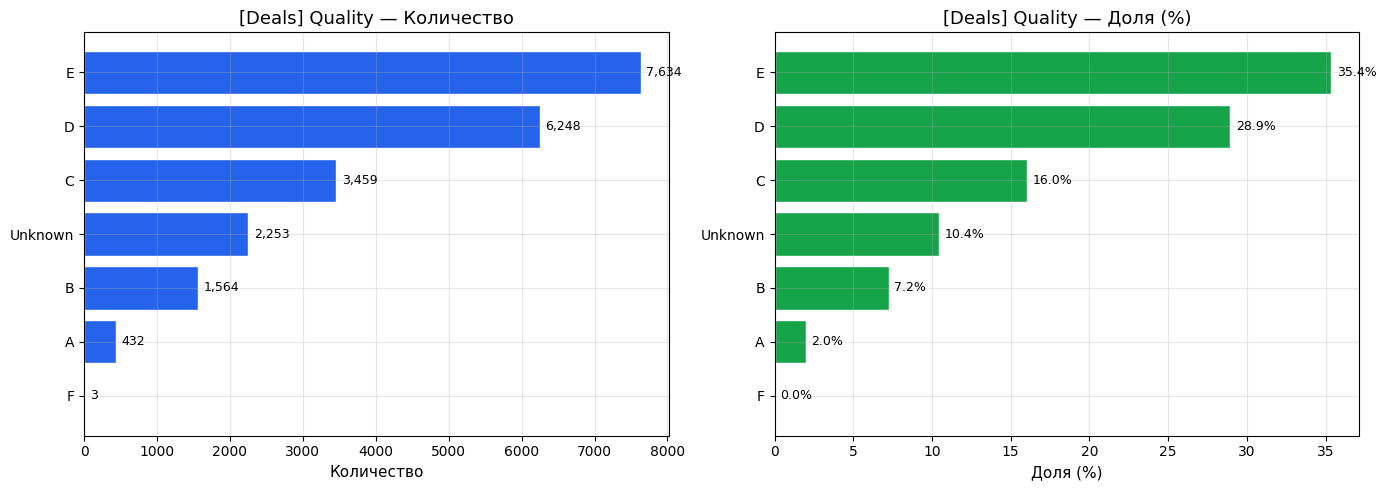

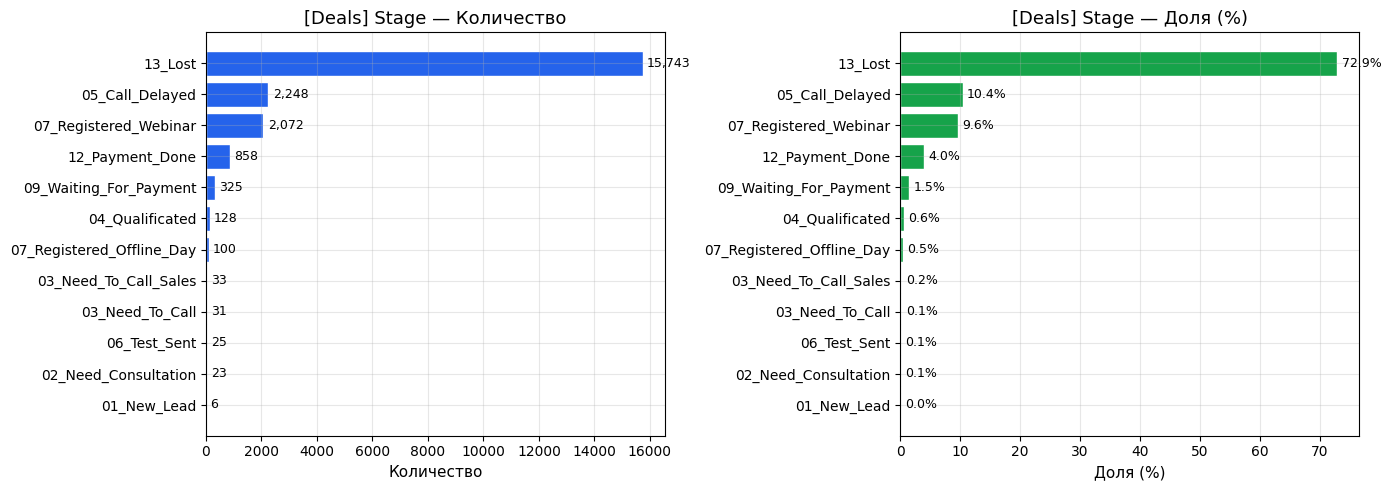

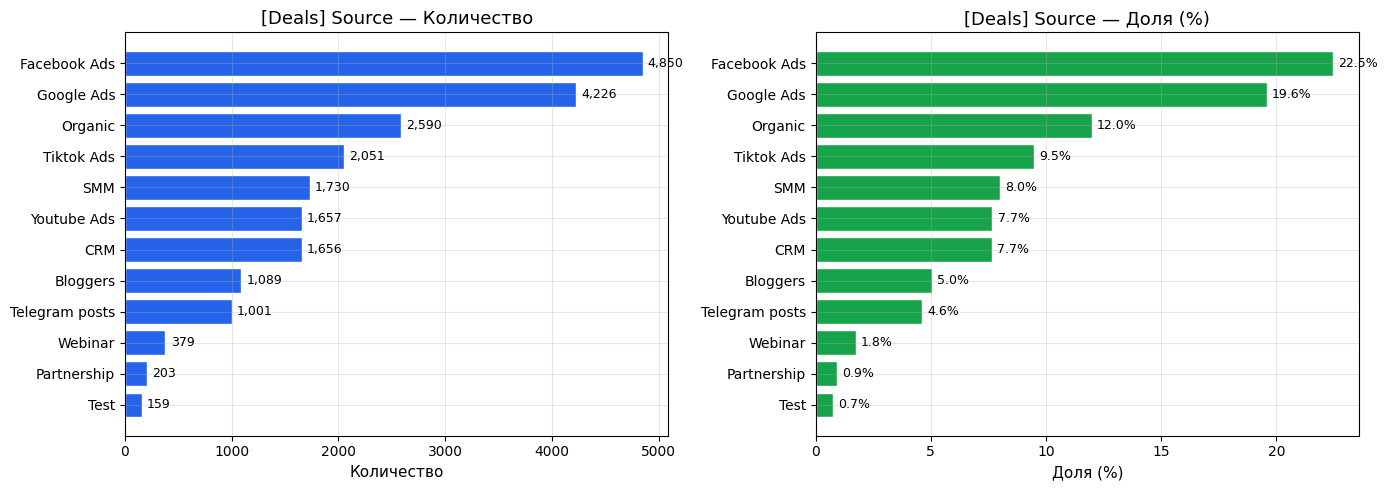

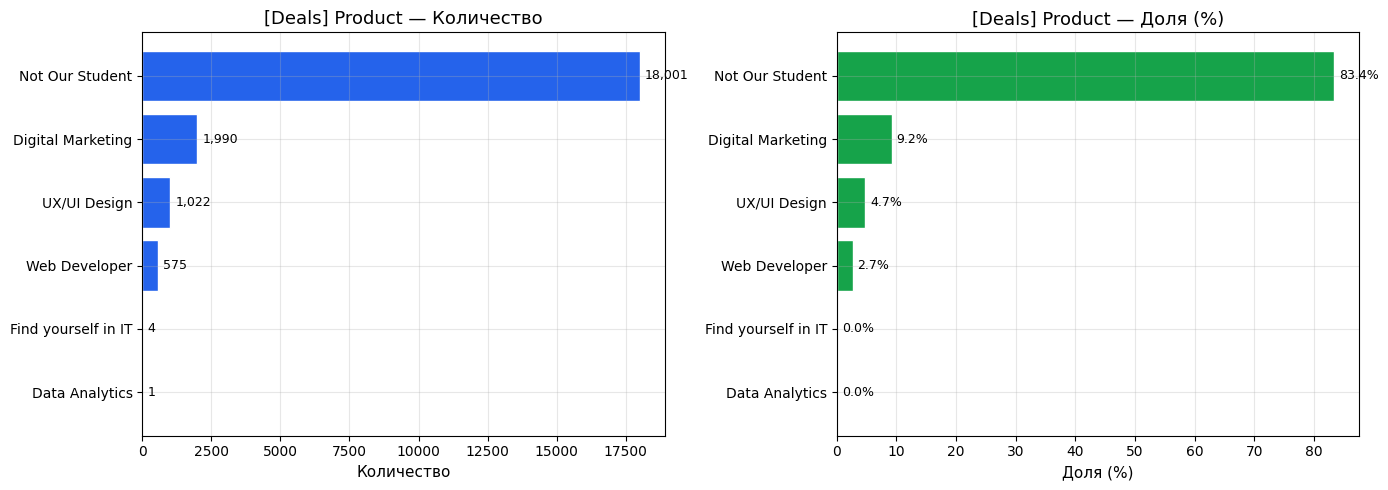

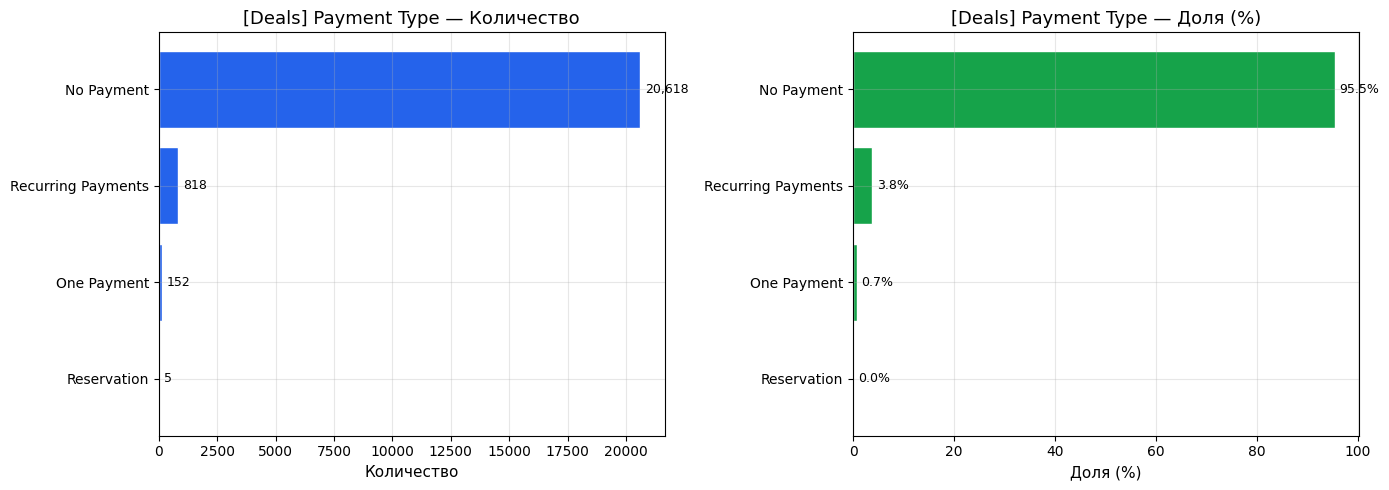

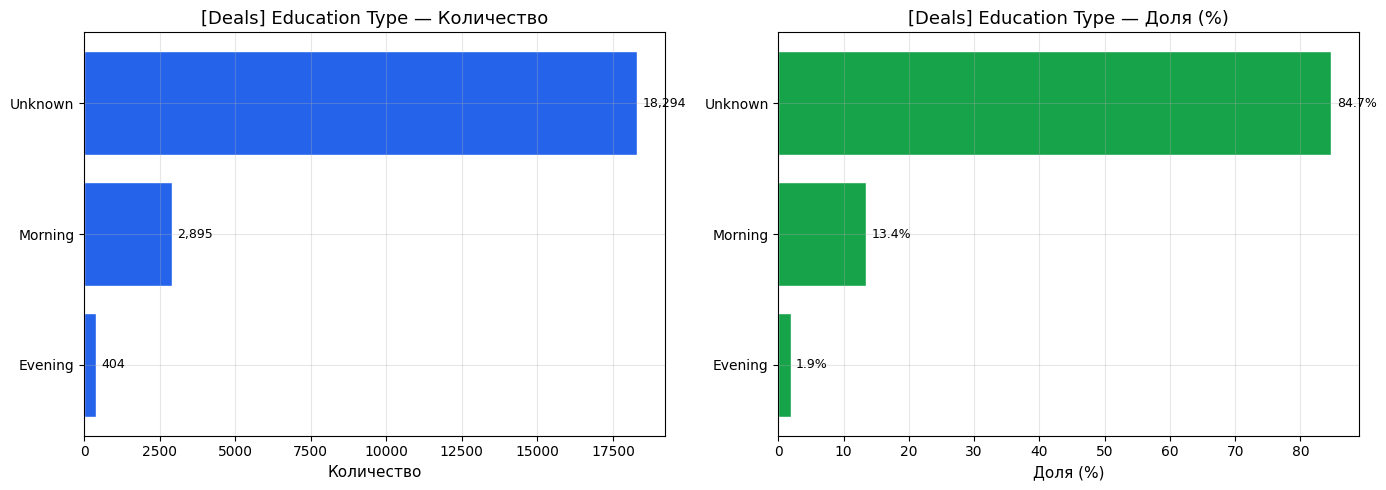

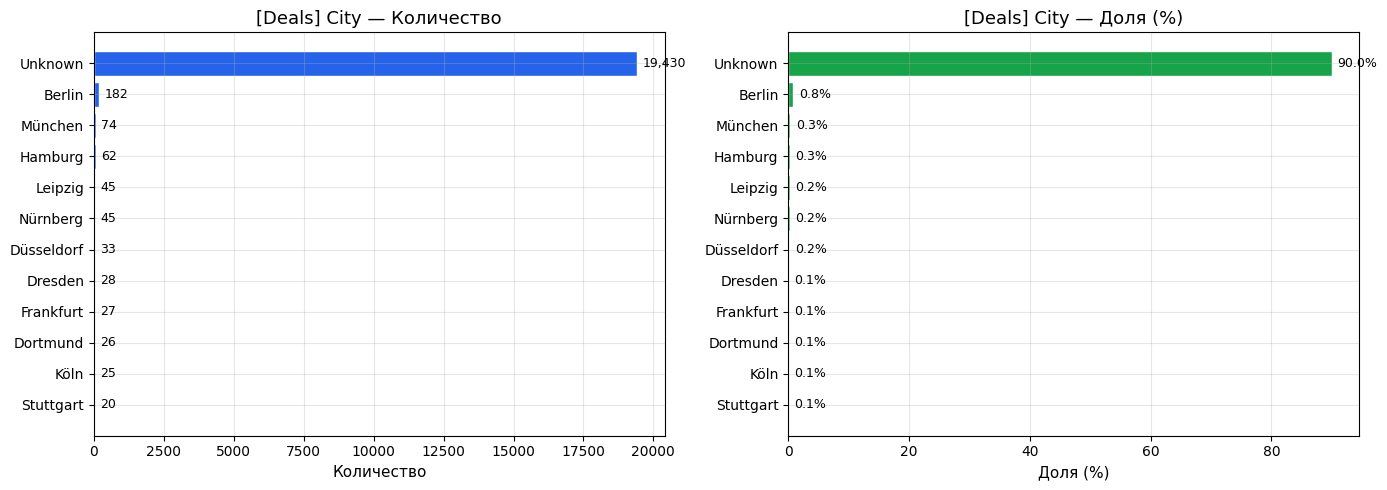

In [71]:
# Project requirement: analyze the following variables:
# Quality, Stage, Source, and Product.
for col in ["Quality", "Stage", "Source", "Product",
            "Payment Type", "Education Type", "City"]:
    if col in deals.columns:
        plot_categorical_dual(
            deals[col],
            col_name=col,
            df_name="Deals",
            top_n=12)

# 6. Visualization of Numerical Variables

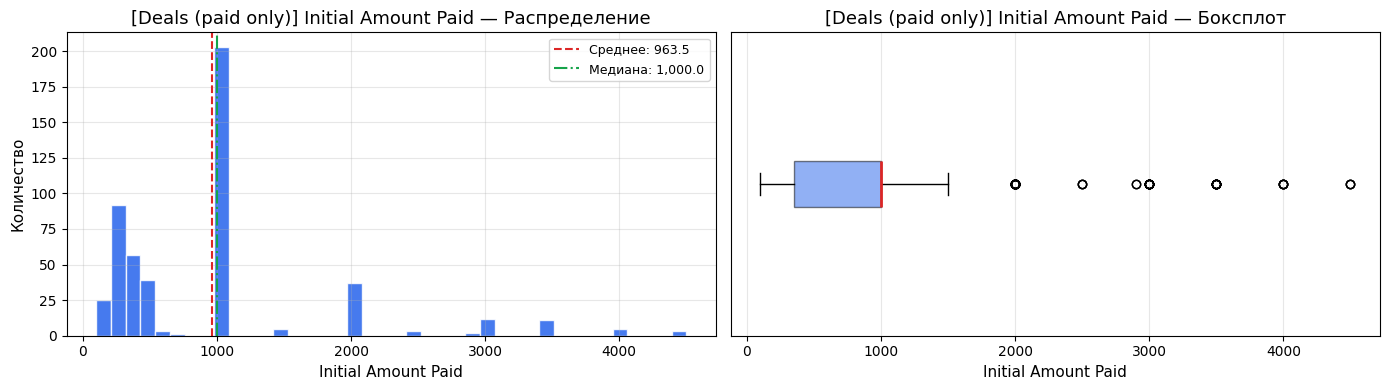

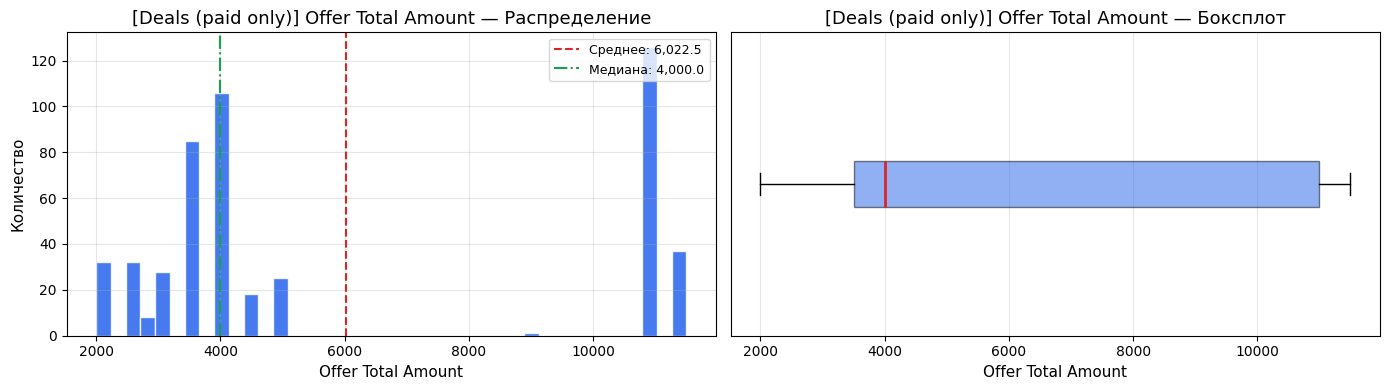

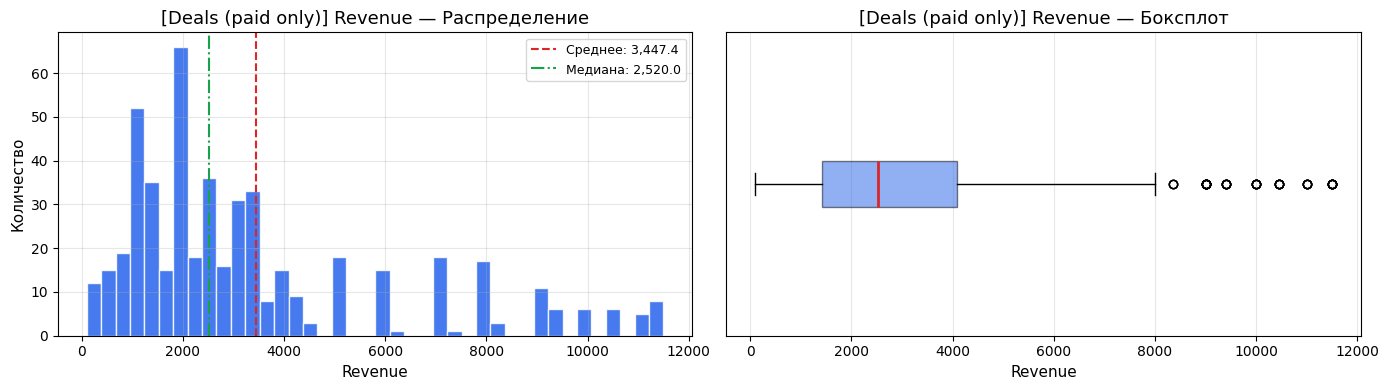

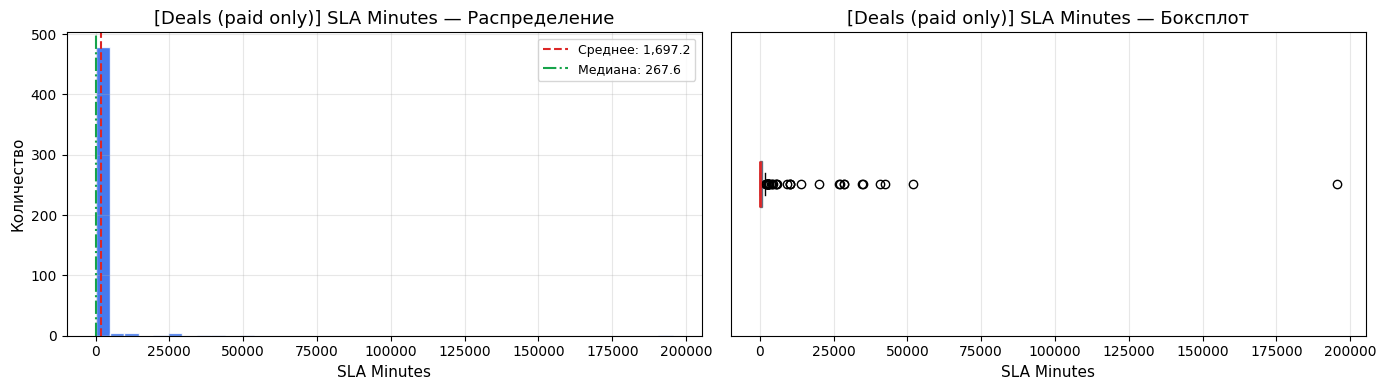

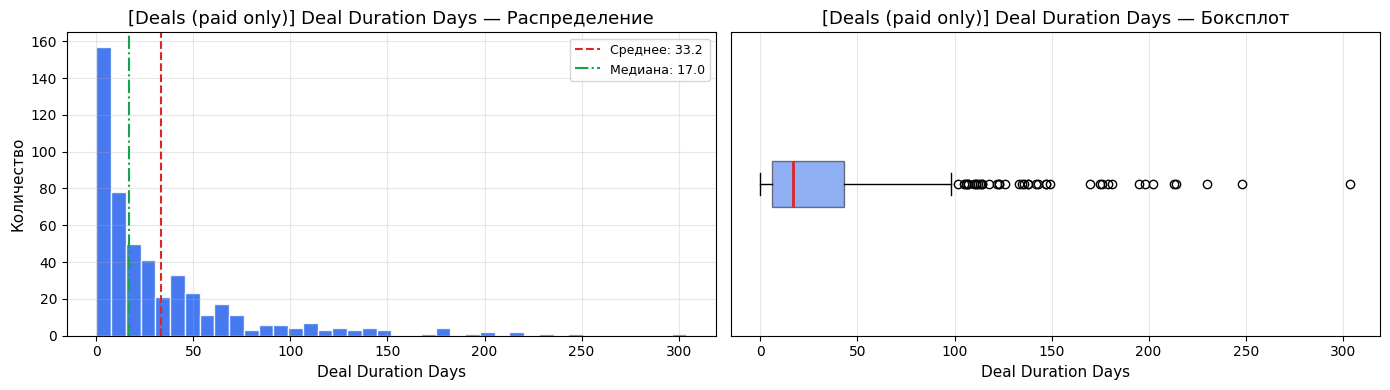

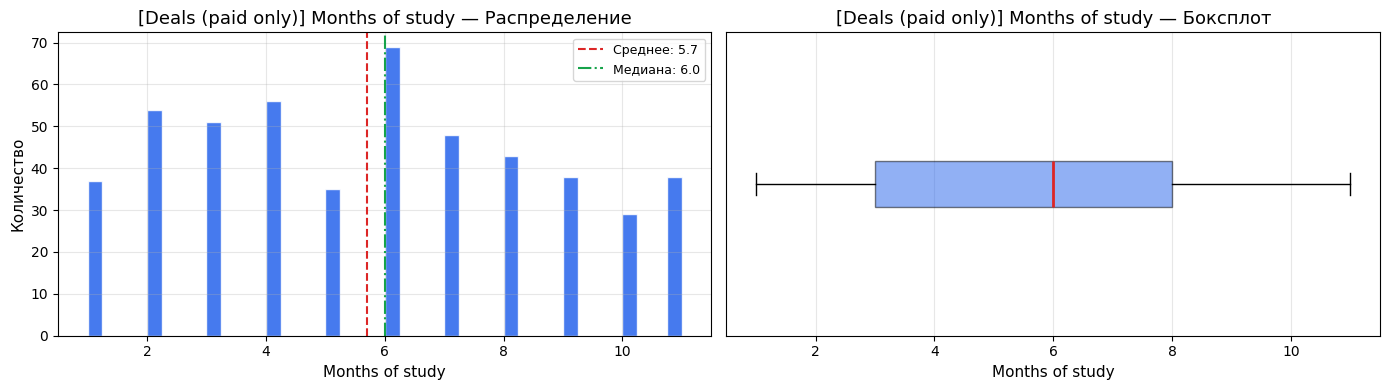

In [78]:
plot_numeric_report(
    paid_deals[paid_deals["Revenue"] > 0][[
        "Initial Amount Paid",
        "Offer Total Amount",
        "Revenue",
        "SLA Minutes",
        "Deal Duration Days",
        "Months of study"
    ]].dropna(),
    df_name="Deals (paid only)"
)

# BLOCK 2: TIME SERIES ANALYSIS

# 7. Monthly Trends in Deals and Calls

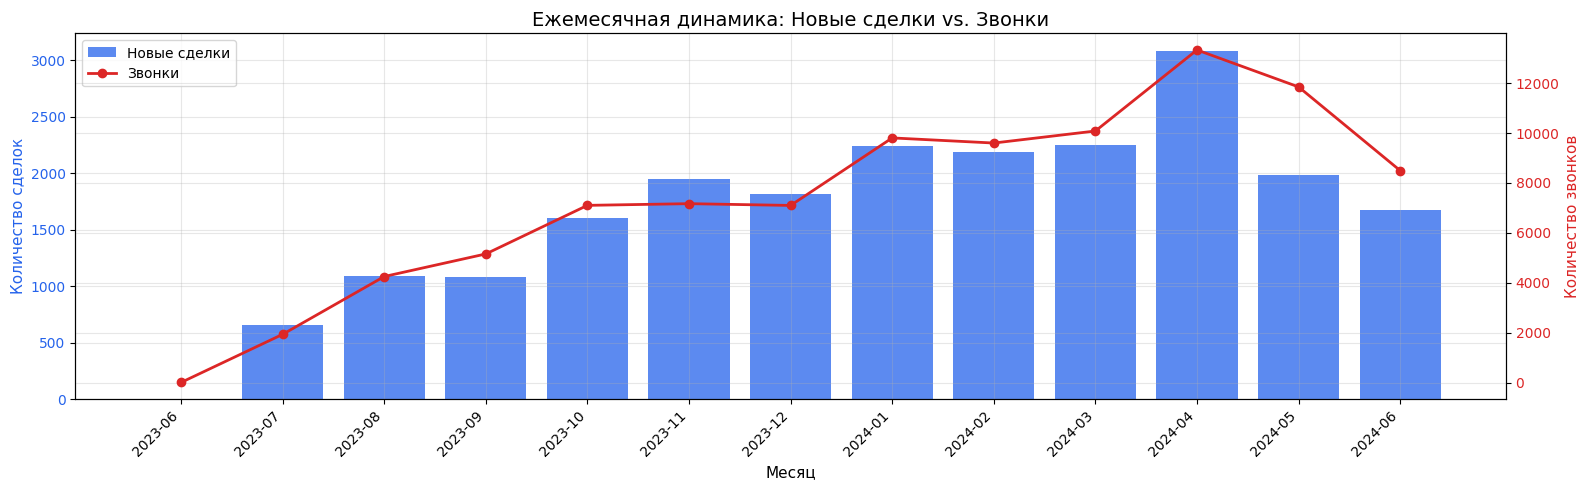

Корреляция между сделками и звонками: 0.956
Вывод: сильная положительная связь, больше звонков = больше сделок


In [79]:
# Project requirements:
# 1. Analyze the trend in deal creation and its relationship with call activity.
# 2. Analyze the distribution of closing times and deal duration.

# Deals by month
deals_monthly = (
    deals
    .groupby(deals["Created Time"].dt.to_period("M"))
    .size()
    .reset_index(name="deals_count")
)
deals_monthly["month"] = deals_monthly["Created Time"].astype(str)

# Calls by month
calls_monthly = (
    calls
    .groupby(calls["Call Start Time"].dt.to_period("M"))
    .size()
    .reset_index(name="calls_count")
)
calls_monthly["month"] = calls_monthly["Call Start Time"].astype(str)

# Merge datasets
merged = pd.merge(
    deals_monthly[["month", "deals_count"]],
    calls_monthly[["month", "calls_count"]],
    on="month", how="outer"
).fillna(0).sort_values("month").reset_index(drop=True)

# Combined chart
fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.bar(
    merged["month"], merged["deals_count"],
    color="#2563EB", alpha=0.75, label="New Deals"
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Deals", color="#2563EB")
ax1.tick_params(axis="y", labelcolor="#2563EB")

ax2 = ax1.twinx()
ax2.plot(
    merged["month"], merged["calls_count"],
    color="#DC2626", marker="o", linewidth=2, label="Calls")

ax2.set_ylabel("Number of Calls", color="#DC2626")
ax2.tick_params(axis="y", labelcolor="#DC2626")

plt.title("Monthly Trend: New Deals vs. Calls", fontsize=14)
plt.xticks(rotation=45, ha="right")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_xticks(range(len(merged)))
ax1.set_xticklabels(merged["month"], rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Correlation
corr = merged["deals_count"].corr(merged["calls_count"])
print(f"Correlation between deals and calls: {corr:.3f}")
print("Conclusion: " + (
    "strong positive relationship — more calls are associated with more deals"
    if corr > 0.6 else
    "moderate relationship" if corr > 0.3 else
    "weak or no relationship"))

#  8. Monthly Revenue Trend

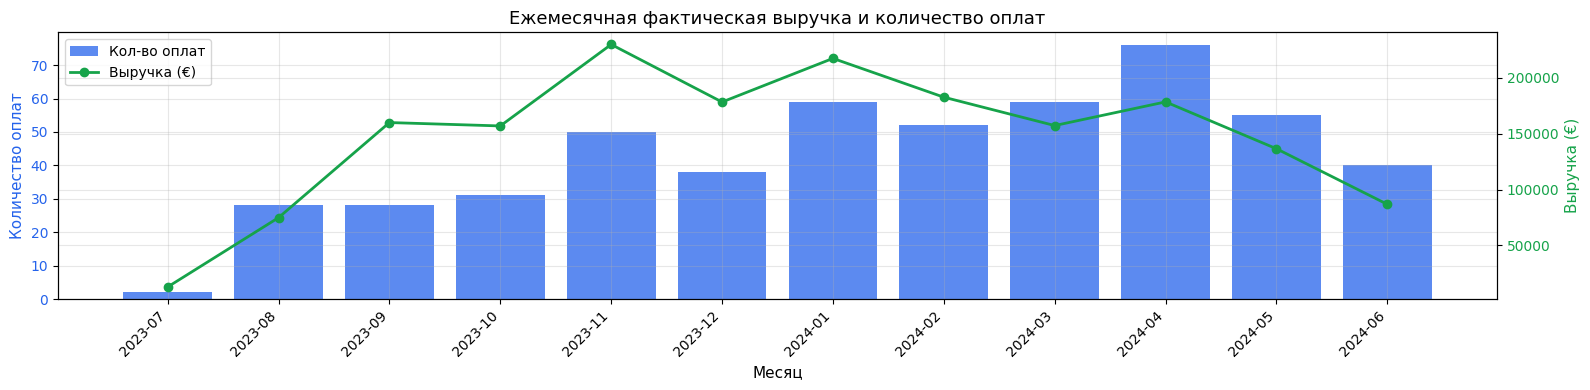

Пиковый месяц по выручке: 2023-11 — €229,805


In [80]:
# Group by closing month using the Revenue metric.

revenue_monthly = (
    paid_deals[paid_deals["Revenue"] > 0]
    .groupby(paid_deals["Closing Date"].dt.to_period("M"))
    .agg(
        payments=("Id", "count"),
        revenue=("Revenue", "sum")
    )
    .reset_index()
)
revenue_monthly["month"] = revenue_monthly["Closing Date"].astype(str)

fig, ax1 = plt.subplots(figsize=(16, 4))

ax1.bar(
    revenue_monthly["month"], revenue_monthly["payments"],
    color="#2563EB", alpha=0.75, label="Number of Payments"
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Payments", color="#2563EB")
ax1.tick_params(axis="y", labelcolor="#2563EB")

ax2 = ax1.twinx()
ax2.plot(
    revenue_monthly["month"], revenue_monthly["revenue"],
    color="#16A34A", marker="o", linewidth=2, label="Revenue (€)"
)
ax2.set_ylabel("Revenue (€)", color="#16A34A")
ax2.tick_params(axis="y", labelcolor="#16A34A")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Monthly Recognized Revenue and Number of Payments",
          fontsize=13)
ax1.set_xticks(range(len(revenue_monthly)))
ax1.set_xticklabels(revenue_monthly["month"], rotation=45, ha="right")
plt.tight_layout()
plt.show()

peak = revenue_monthly.loc[revenue_monthly["revenue"].idxmax()]
print(f"Peak revenue month: {peak['month']} — €{peak['revenue']:,.0f}")

#  9. Time from Deal Creation to Payment

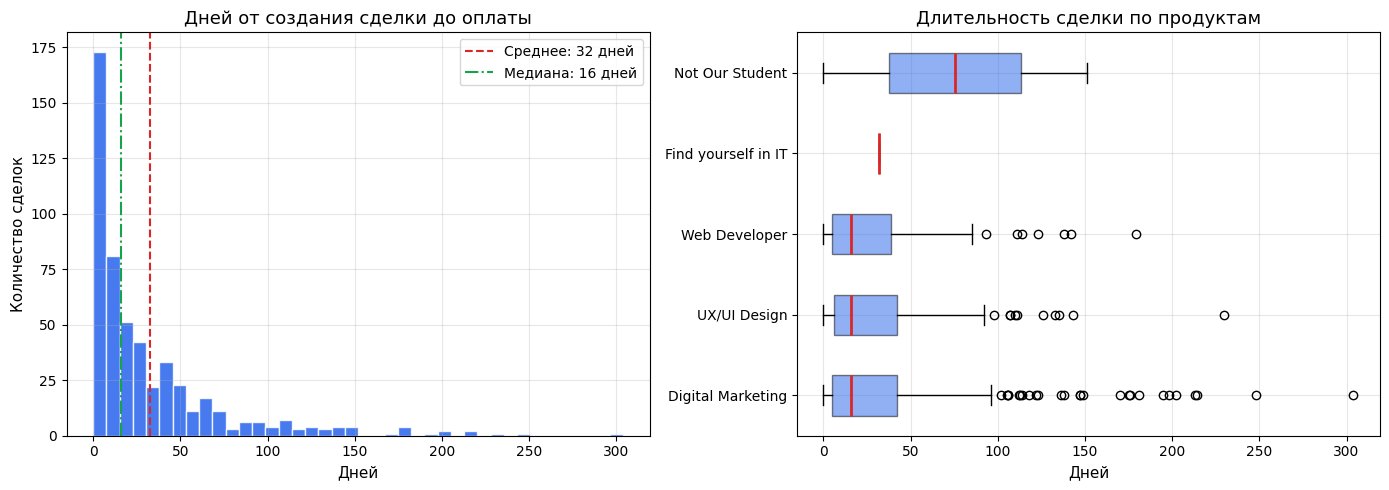

Средняя длительность до оплаты: 32 дней
Медианная длительность: 16 дней


In [81]:
# Paid deals only with available deal duration
paid_with_duration = paid_deals.dropna(subset=["Deal Duration Days"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(
    paid_with_duration["Deal Duration Days"],
    bins=40, color="#2563EB", edgecolor="white", alpha=0.85)

axes[0].axvline(
    paid_with_duration["Deal Duration Days"].mean(),
    color="#DC2626", linestyle="--",
    label=f"Mean: {paid_with_duration['Deal Duration Days'].mean():.0f} days")

axes[0].axvline(
    paid_with_duration["Deal Duration Days"].median(),
    color="#16A34A", linestyle="-.",
    label=f"Median: {paid_with_duration['Deal Duration Days'].median():.0f} days")

axes[0].set_title("Days from Deal Creation to Payment", fontsize=13)
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Number of Deals")
axes[0].legend()

# Boxplot by product
prod_dur = paid_with_duration.dropna(subset=["Product"])
prod_dur = prod_dur[prod_dur["Product"] != "Unknown"]
products_sorted = (
    prod_dur.groupby("Product", observed=True)["Deal Duration Days"]
    .median()
    .sort_values()
    .index
)
data_per_product = [
    prod_dur[prod_dur["Product"] == p]["Deal Duration Days"].values
    for p in products_sorted
]
axes[1].boxplot(
    data_per_product,
    labels=products_sorted,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#2563EB", alpha=0.5),
    medianprops=dict(color="#DC2626", linewidth=2)
)
axes[1].set_title("Deal Duration by Product", fontsize=13)
axes[1].set_xlabel("Days")

plt.tight_layout()
plt.show()

print(f"Average time to payment: {paid_with_duration['Deal Duration Days'].mean():.0f} days")
print(f"Median time to payment: {paid_with_duration['Deal Duration Days'].median():.0f} days")

# BLOCK 3: CAMPAIGN PERFORMANCE ANALYSIS

In [82]:
# Project requirements:
# 1. Compare campaigns by lead generation and conversion rate.
# 2. Evaluate marketing sources (Source).

# Exclude "not set" campaigns for a cleaner campaign analysis.
deals_with_campaign = deals[
    deals["Campaign"] != "not set"
].copy()

campaign_perf = (
    deals_with_campaign
    .groupby("Campaign", observed=True)
    .agg(
        total_leads=("Id", "count"),
        paid_deals=("Is Paid", "sum"),
    )
    .reset_index()
)

campaign_perf["conversion_pct"] = (
    campaign_perf["paid_deals"] / campaign_perf["total_leads"] * 100
).round(2)

# Join campaign spending from the Spend dataset.
spend_by_campaign = (
    spend
    .groupby("Campaign", observed=True)["Spend"]
    .sum()
    .reset_index()
    .rename(columns={"Spend": "total_spend"})
)

campaign_perf = campaign_perf.merge(
    spend_by_campaign, on="Campaign", how="left"
)

campaign_perf["cac"] = (
    campaign_perf["total_spend"] / campaign_perf["paid_deals"]
).round(2)

campaign_perf = campaign_perf.sort_values("paid_deals", ascending=False)

print("Top 15 campaigns by number of paid deals:")
print(campaign_perf.head(15).to_string(index=False))

Топ-15 кампаний по количеству оплат:
                         Campaign  total_leads  paid_deals  conversion_pct  total_spend    cac
performancemax_digitalmarkt_ru_DE         2653         112            4.22          NaN    NaN
                youtube_shorts_DE         1635          53            3.24     14149.22 266.97
                  02.07.23wide_DE          975          52            5.33      6913.60 132.95
                12.07.2023wide_DE         1575          48            3.05      9471.52 197.32
                    03.07.23women          612          31            5.07      4219.75 136.12
         04.07.23recentlymoved_DE          750          31            4.13      4523.31 145.91
                           Dis_DE          581          30            5.16          NaN    NaN
                   07.07.23LAL_DE          542          28            5.17      4200.37 150.01
        12.09.23interests_Uxui_DE          531          27            5.08      3753.06 139.00
           24

# 11. Campaign Visualization

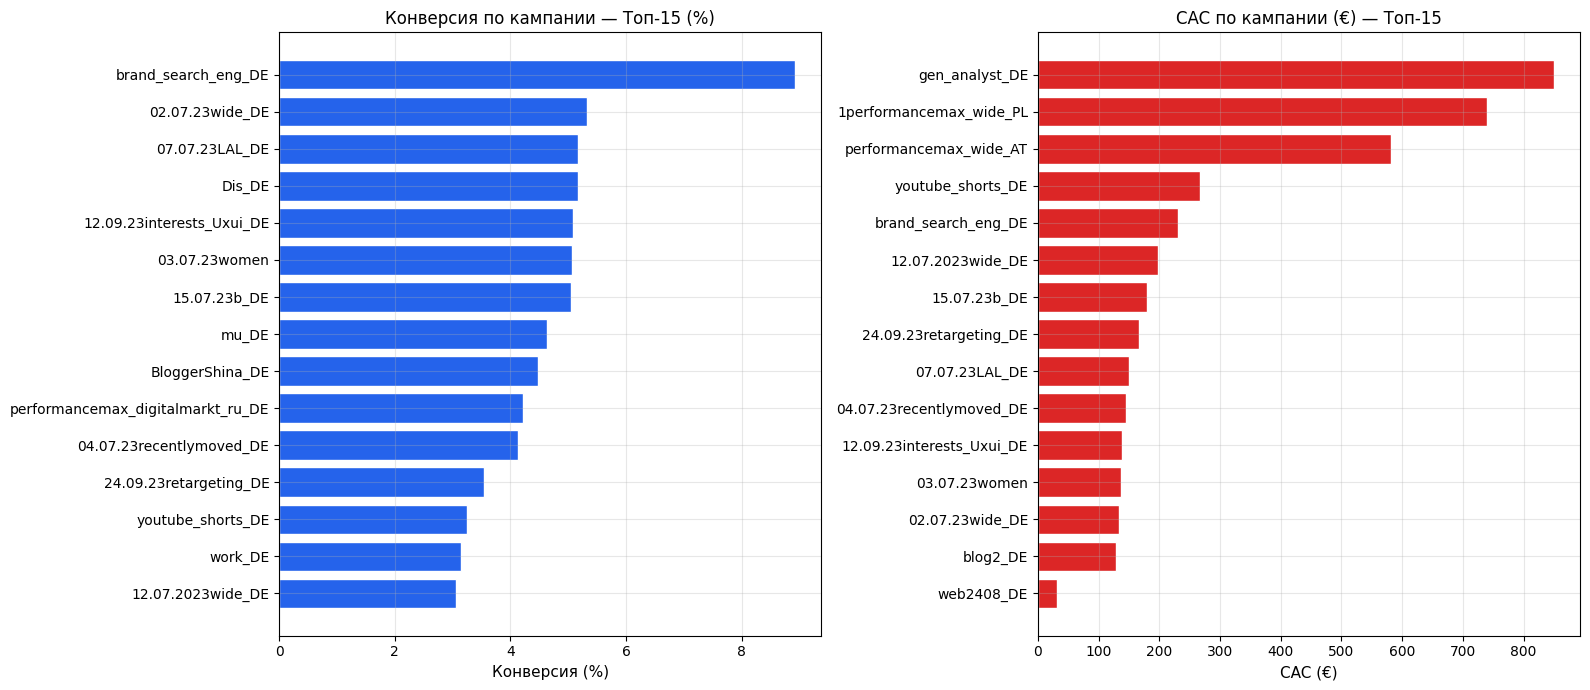

In [84]:
top15 = campaign_perf.head(15).copy()

# Sorting
top15_conversion = top15.sort_values("conversion_pct", ascending=False)
top15_cac = (
    campaign_perf.dropna(subset=["cac"])
    .head(15)
    .sort_values("cac", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Conversion Rate
axes[0].barh(
    top15_conversion["Campaign"][::-1],
    top15_conversion["conversion_pct"][::-1],
    color="#2563EB",
    edgecolor="white"
)
axes[0].set_title("Campaign Conversion Rate — Top 15 (%)", fontsize=12)
axes[0].set_xlabel("Conversion Rate (%)")

# CAC
axes[1].barh(
    top15_cac["Campaign"][::-1],
    top15_cac["cac"][::-1],
    color="#DC2626",
    edgecolor="white"
)
axes[1].set_title("Campaign CAC (€) — Top 15", fontsize=12)
axes[1].set_xlabel("CAC (€)")

plt.tight_layout()
plt.show()

# 12. Traffic Sources (Source)

Эффективность источников трафика:
        Source  total  paid  revenue  conversion_pct  total_spend  total_clicks    cpa    roi
  Facebook Ads   4850   202 951690.0            4.16     33754.72         48133 167.10 2719.4
    Google Ads   4226   173 752400.0            4.09     57798.60        248487 334.10 1201.8
       Organic   2590   147 615466.0            5.68         0.00             0   0.00    inf
           SMM   1730    91 329210.0            5.26      7269.52            32  79.88 4428.6
    Tiktok Ads   2051    56 235235.0            2.73     11985.67         28268 214.03 1862.6
   Youtube Ads   1657    53 218350.0            3.20     14633.33         59061 276.10 1392.1
Telegram posts   1001    40 165050.0            4.00      6860.36         16776 171.51 2305.9
      Bloggers   1089    39 162006.0            3.58     13439.00         14224 344.59 1105.5
       Webinar    379    26 132885.0            6.86      2874.04          3241 110.54 4523.6
           CRM   1656    2

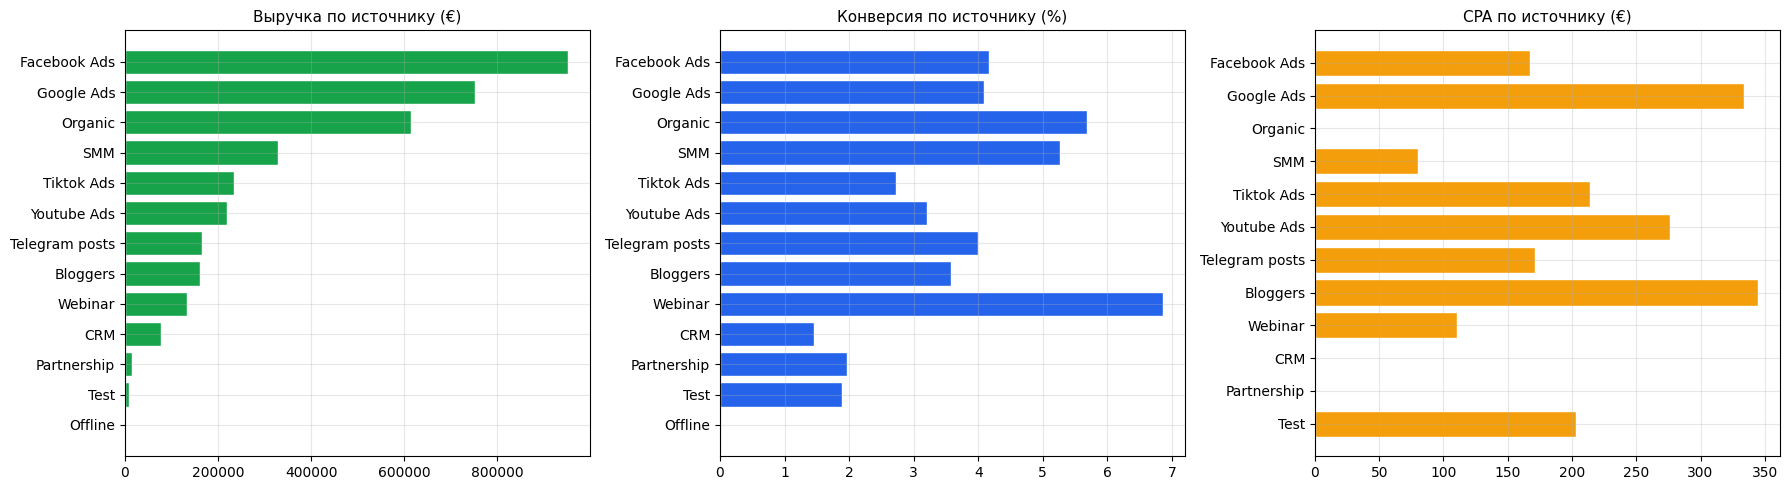

In [87]:
source_perf = (
    deals
    .groupby("Source", observed=True)
    .agg(
        total=("Id", "count"),
        paid=("Is Paid", "sum"),
        revenue=("Revenue", "sum"),
    )
    .reset_index()
)
source_perf["conversion_pct"] = (
    source_perf["paid"] / source_perf["total"] * 100
).round(2)

spend_by_source = (
    spend.groupby("Source", observed=True)
    .agg(total_spend=("Spend", "sum"), total_clicks=("Clicks", "sum"))
    .reset_index()
)
source_perf = source_perf.merge(spend_by_source, on="Source", how="left")
source_perf["cpa"] = (
    source_perf["total_spend"] / source_perf["paid"]
).round(2)
source_perf["roi"] = (
    (source_perf["revenue"] - source_perf["total_spend"])
    / source_perf["total_spend"] * 100
).round(1)
source_perf = source_perf.sort_values("revenue", ascending=False)

print("Traffic Source Performance:")
print(source_perf.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(
    source_perf["Source"][::-1], source_perf["revenue"][::-1],
    color="#16A34A", edgecolor="white"
)
axes[0].set_title("Revenue by Traffic Source (€)", fontsize=11)

axes[1].barh(
    source_perf["Source"][::-1], source_perf["conversion_pct"][::-1],
    color="#2563EB", edgecolor="white"
)
axes[1].set_title("Conversion Rate by Traffic Source (%)", fontsize=11)

axes[2].barh(
    source_perf.dropna(subset=["cpa"])["Source"][::-1],
    source_perf.dropna(subset=["cpa"])["cpa"][::-1],
    color="#F59E0B", edgecolor="white"
)
axes[2].set_title("CPA by Traffic Source (€)", fontsize=11)

plt.tight_layout()
plt.show()

# BLOCK 4: SALES TEAM ANALYSIS

# 13. Sales Representative Performance

In [88]:
# Project requirement: analyze sales representatives by
# number of deals, conversion rate, and total sales revenue.

manager_perf = (
    deals
    .groupby("Deal Owner Name", observed=True)
    .agg(
        total_deals=("Id", "count"),
        paid_deals=("Is Paid", "sum"),
        total_revenue=("Revenue", "sum"),
        avg_sla=("SLA Minutes", "mean"),
    )
    .reset_index()
)

manager_perf["conversion_pct"] = (
    manager_perf["paid_deals"] / manager_perf["total_deals"] * 100
).round(2)

manager_perf["avg_deal_value"] = (
    manager_perf["total_revenue"] / manager_perf["paid_deals"]
).round(0)

manager_perf["avg_sla"] = manager_perf["avg_sla"].round(0)
manager_perf = manager_perf.sort_values("total_revenue", ascending=False)

print("Top 15 Sales Representatives by Revenue:")
print(manager_perf.head(15).to_string(index=False))

Топ-15 менеджеров по выручке:
Deal Owner Name  total_deals  paid_deals  total_revenue  avg_sla  conversion_pct  avg_deal_value
  Charlie Davis         2963         148       613995.0   2234.0            4.99          4149.0
  Ulysses Adams         2165         141       555040.0   1312.0            6.51          3936.0
   Julia Nelson         2241          93       451547.0   2035.0            4.15          4855.0
  Oliver Taylor          163          50       390575.0   1968.0           30.67          7812.0
Paula Underwood         1862          93       331645.0   1087.0            4.99          3566.0
 Quincy Vincent         1884          65       240020.0   1283.0            3.45          3693.0
   Cara Iverson         1056          27       199670.0   1096.0            2.56          7395.0
  Victor Barnes         1232          44       180490.0   3013.0            3.57          4102.0
     Nina Scott         1283          46       177950.0   2038.0            3.59          3868.0


# 14. Sales Representative Visualization

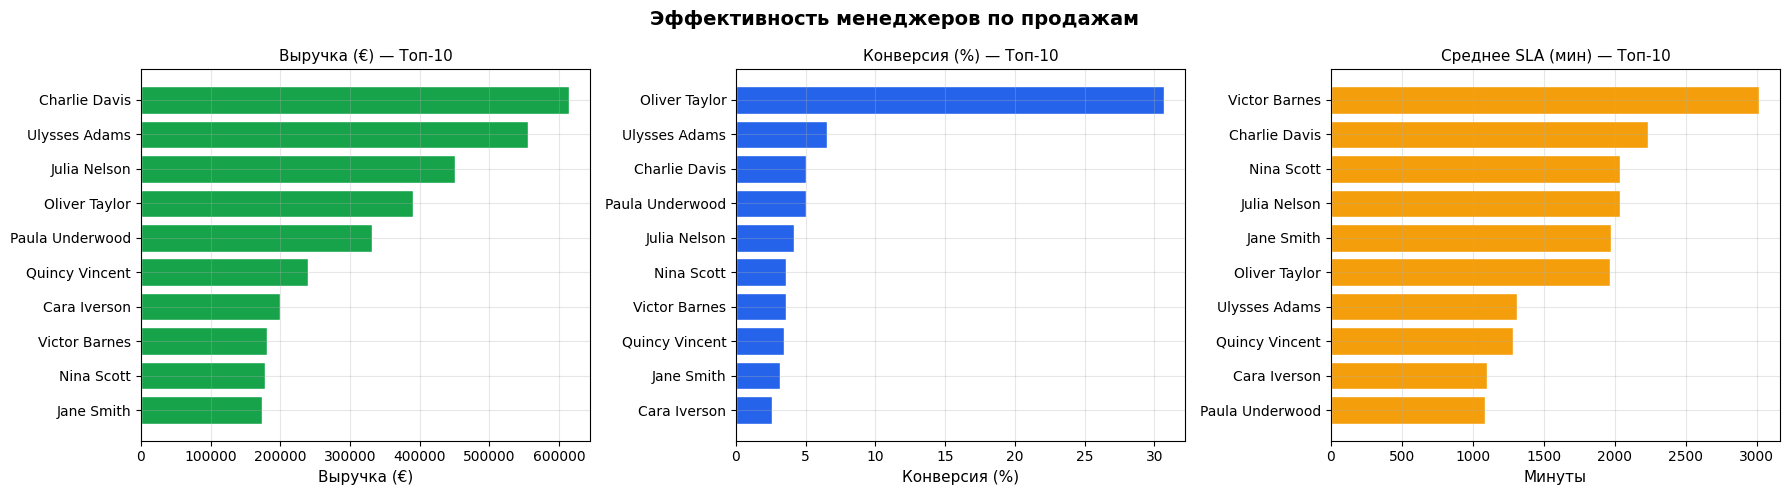

In [89]:
top10 = manager_perf.head(10).copy()

# Sort for each performance metric
top10_revenue = top10.sort_values("total_revenue", ascending=False)
top10_conversion = top10.sort_values("conversion_pct", ascending=False)
top10_sla = top10.sort_values("avg_sla", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Revenue
axes[0].barh(
    top10_revenue["Deal Owner Name"][::-1],
    top10_revenue["total_revenue"][::-1],
    color="#16A34A",
    edgecolor="white"
)
axes[0].set_title("Revenue (€) — Top 10", fontsize=11)
axes[0].set_xlabel("Revenue (€)")

# Conversion Rate
axes[1].barh(
    top10_conversion["Deal Owner Name"][::-1],
    top10_conversion["conversion_pct"][::-1],
    color="#2563EB",
    edgecolor="white"
)
axes[1].set_title("Conversion Rate (%) — Top 10", fontsize=11)
axes[1].set_xlabel("Conversion Rate (%)")

# Average SLA
axes[2].barh(
    top10_sla["Deal Owner Name"][::-1],
    top10_sla["avg_sla"][::-1],
    color="#F59E0B",
    edgecolor="white"
)
axes[2].set_title("Average SLA (Minutes) — Top 10", fontsize=11)
axes[2].set_xlabel("Minutes")

plt.suptitle(
    "Sales Representative Performance",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# BLOCK 5: PAYMENT AND PRODUCT ANALYSIS

# 15. Payment Types

Анализ типов оплат:
      Payment Type  total  paid  avg_initial   avg_offer  avg_revenue  total_rev  conversion_pct
       One Payment    152   124  2598.368421 3879.618421  2598.368421   394952.0           81.58
Recurring Payments    818   718   878.002451 8033.793146  3995.073350  3267970.0           87.78
       Reservation      5     1   180.000000 3100.000000     0.000000        0.0           20.00


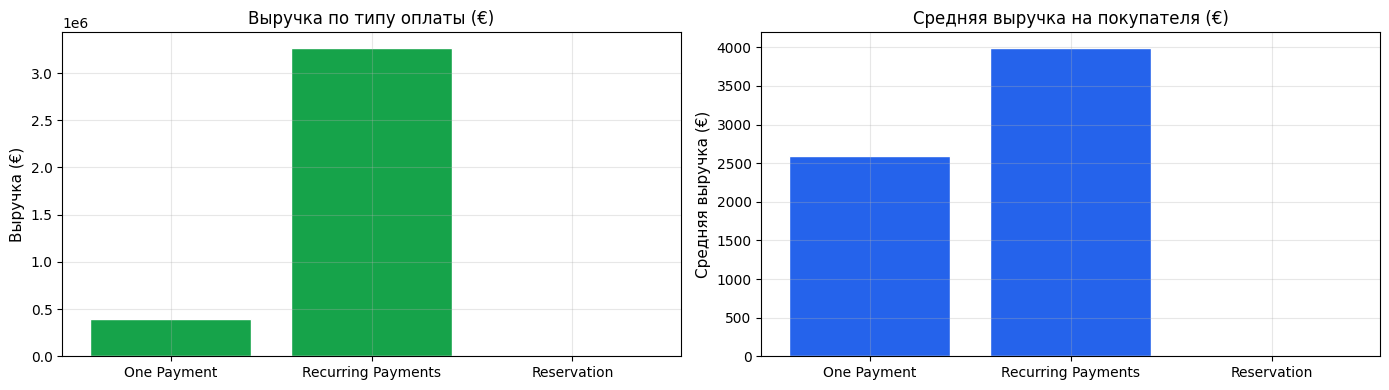

In [90]:
# Project requirements:
# 1. Analyze payment types and their impact on success.
# 2. Analyze the popularity and performance of products
#    and learning formats.

payment_analysis = (
    deals[deals["Payment Type"] != "No Payment"]
    .groupby("Payment Type", observed=True)
    .agg(
        total=("Id", "count"),
        paid=("Is Paid", "sum"),
        avg_initial=("Initial Amount Paid", "mean"),
        avg_offer=("Offer Total Amount", "mean"),
        avg_revenue=("Revenue", "mean"),
        total_rev=("Revenue", "sum"),
    )
    .reset_index()
)
payment_analysis["conversion_pct"] = (
    payment_analysis["paid"] / payment_analysis["total"] * 100
).round(2)

print("Payment Type Analysis:")
print(payment_analysis.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    payment_analysis["Payment Type"],
    payment_analysis["total_rev"],
    color="#16A34A", edgecolor="white"
)
axes[0].set_title("Revenue by Payment Type (€)", fontsize=12)
axes[0].set_ylabel("Revenue (€)")

axes[1].bar(
    payment_analysis["Payment Type"],
    payment_analysis["avg_revenue"],
    color="#2563EB", edgecolor="white"
)
axes[1].set_title("Average Revenue per Customer (€)", fontsize=12)
axes[1].set_ylabel("Average Revenue (€)")

plt.tight_layout()
plt.show()

# 16. Products: Popularity and Conversion Rate

Анализ продуктов:
            Product  total  paid  avg_revenue  total_revenue   avg_offer  conversion_pct
  Digital Marketing   1990   474  1155.062814      2298575.0 9750.280303           23.82
       UX/UI Design   1022   229   962.783757       983965.0 9454.777070           22.41
      Web Developer    575   137   658.052174       378380.0 5366.296296           23.83
Find yourself in IT      4     1     0.250000            1.0    0.333333           25.00
     Data Analytics      1     0     0.000000            0.0 6000.000000            0.00


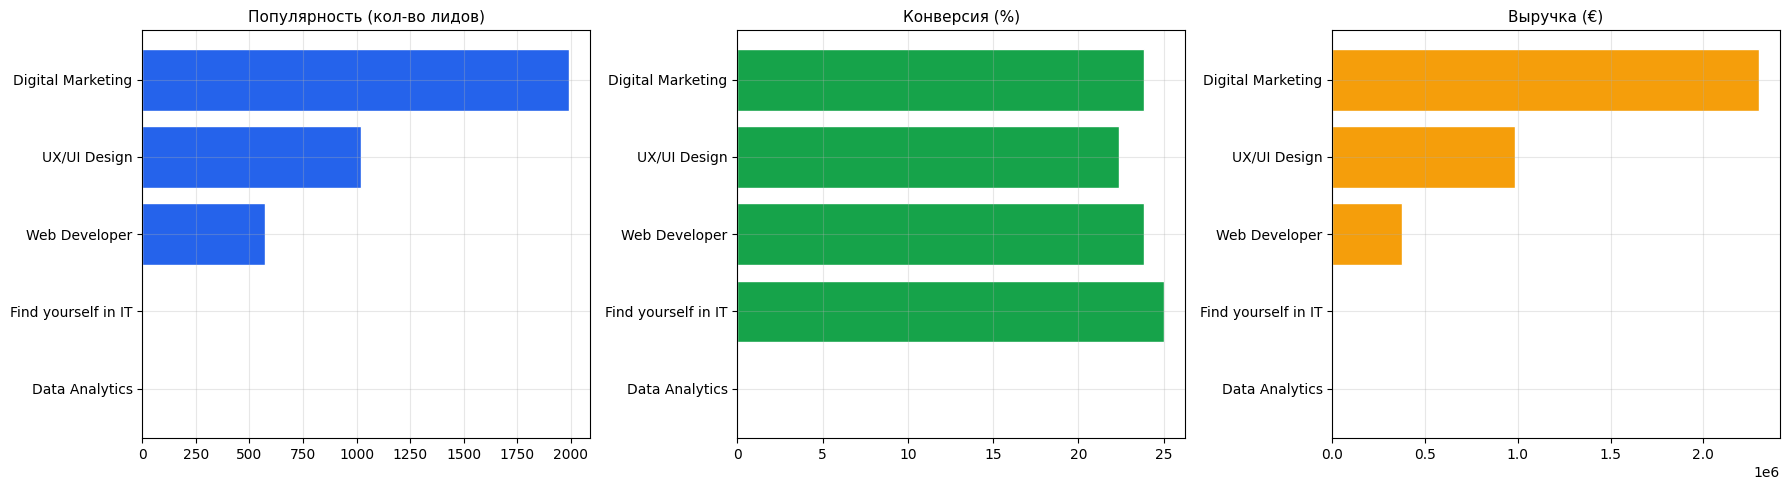

In [91]:
product_analysis = (
    deals[~deals["Product"].isin(["Not Our Student"])]
    .groupby("Product", observed=True)
    .agg(
        total=("Id", "count"),
        paid=("Is Paid", "sum"),
        avg_revenue=("Revenue", "mean"),
        total_revenue=("Revenue", "sum"),
        avg_offer=("Offer Total Amount", "mean"),
    )
    .reset_index()
)
product_analysis["conversion_pct"] = (
    product_analysis["paid"] / product_analysis["total"] * 100
).round(2)
product_analysis = product_analysis.sort_values(
    "total_revenue", ascending=False
)

print("Product Analysis:")
print(product_analysis.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(
    product_analysis["Product"][::-1],
    product_analysis["total"][::-1],
    color="#2563EB", edgecolor="white"
)
axes[0].set_title("Popularity (Number of Leads)", fontsize=11)

axes[1].barh(
    product_analysis["Product"][::-1],
    product_analysis["conversion_pct"][::-1],
    color="#16A34A", edgecolor="white"
)
axes[1].set_title("Conversion Rate (%)", fontsize=11)

axes[2].barh(
    product_analysis["Product"][::-1],
    product_analysis["total_revenue"][::-1],
    color="#F59E0B", edgecolor="white"
)
axes[2].set_title("Revenue (€)", fontsize=11)

plt.tight_layout()
plt.show()

# 17. Learning Formats

Типы обучения:
Education Type  total  paid  total_revenue  avg_revenue  conversion_pct
       Morning   2895   662      3143270.0  1085.758204           22.87
       Evening    404   171       429200.0  1062.376238           42.33


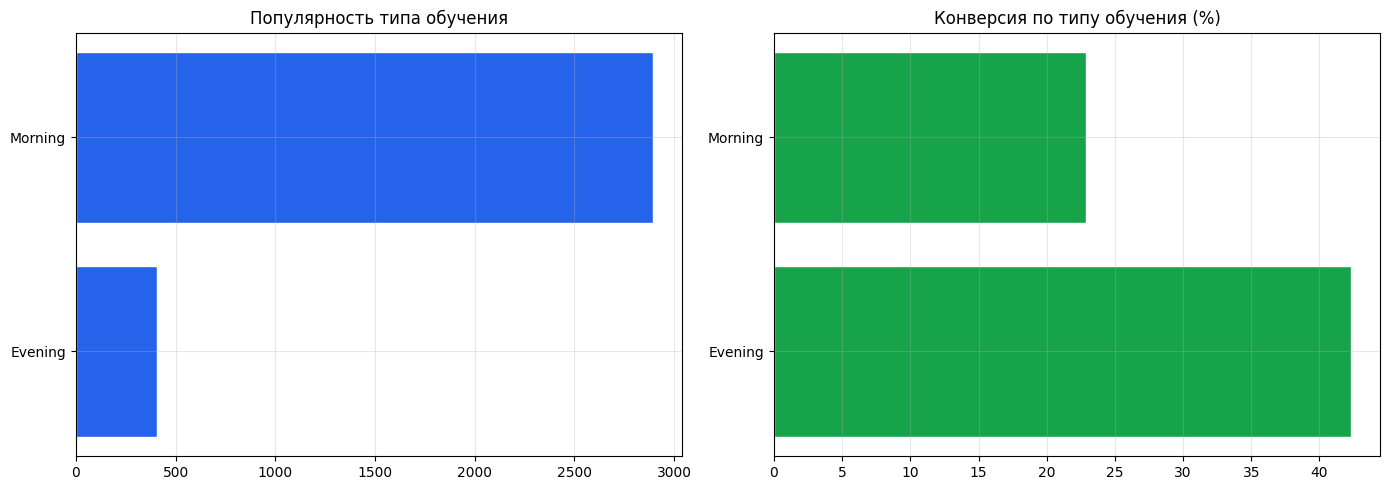

In [92]:
edu_analysis = (
    deals[deals["Education Type"] != "Unknown"]
    .groupby("Education Type", observed=True)
    .agg(
        total=("Id", "count"),
        paid=("Is Paid", "sum"),
        total_revenue=("Revenue", "sum"),
        avg_revenue=("Revenue", "mean"),
    )
    .reset_index()
)
edu_analysis["conversion_pct"] = (
    edu_analysis["paid"] / edu_analysis["total"] * 100
).round(2)
edu_analysis = edu_analysis.sort_values("total_revenue", ascending=False)

print("Learning Formats:")
print(edu_analysis.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    edu_analysis["Education Type"][::-1],
    edu_analysis["total"][::-1],
    color="#2563EB", edgecolor="white"
)
axes[0].set_title("Learning Format Popularity", fontsize=12)

axes[1].barh(
    edu_analysis["Education Type"][::-1],
    edu_analysis["conversion_pct"][::-1],
    color="#16A34A", edgecolor="white"
)
axes[1].set_title("Conversion Rate by Learning Format (%)", fontsize=12)

plt.tight_layout()
plt.show()

# BLOCK 6: GEOGRAPHICAL ANALYSIS

# 18. City Distribution

Топ-15 городов:
      City  total  paid  total_revenue  avg_revenue  conversion_pct
    Berlin    182    78       365830.0  2010.054945           42.86
   München     74    27        91155.0  1231.824324           36.49
   Hamburg     62    22        86525.0  1395.564516           35.48
  Nürnberg     45     9        37500.0   833.333333           20.00
   Leipzig     45    18        72425.0  1609.444444           40.00
Düsseldorf     33     7        39840.0  1207.272727           21.21
   Dresden     28     9        28350.0  1012.500000           32.14
 Frankfurt     27     7        24700.0   914.814815           25.93
  Dortmund     26     4        17850.0   686.538462           15.38
      Köln     25     9        54630.0  2185.200000           36.00
 Stuttgart     20     2        10500.0   525.000000           10.00
  Hannover     19     4        14550.0   765.789474           21.05
  Duisburg     19     5        12900.0   678.947368           26.32
    Bremen     17     5        2

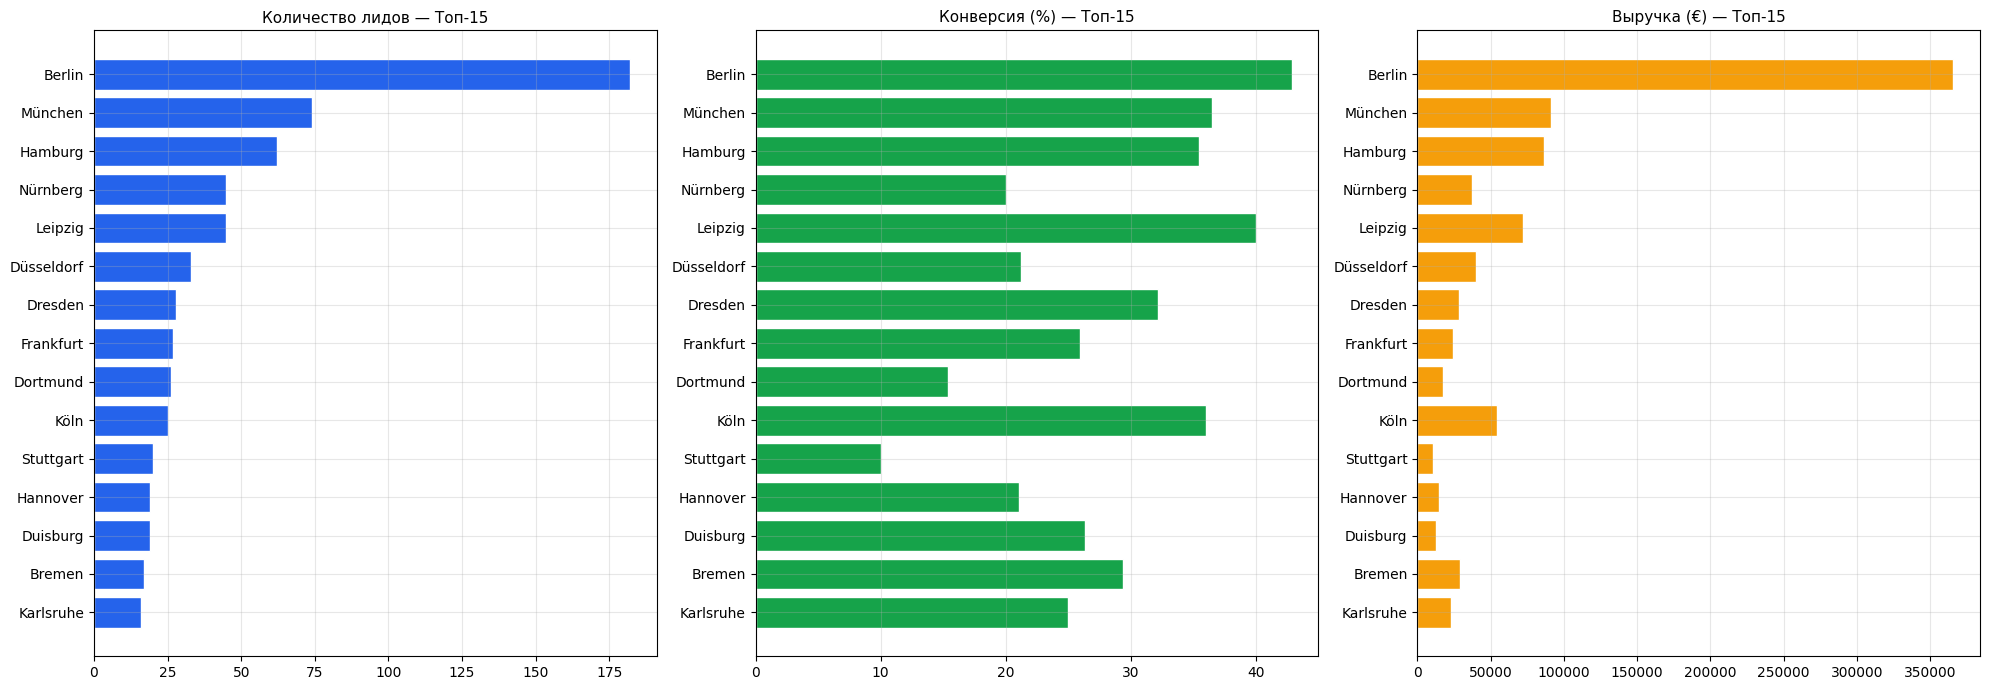

In [96]:
# Project requirements:
# 1. Analyze deal distribution by city.
# 2. Analyze the impact of German language proficiency on conversion rate.

city_analysis = (
    deals[deals["City"] != "Unknown"]
    .groupby("City", observed=True)
    .agg(
        total=("Id", "count"),
        paid=("Is Paid", "sum"),
        total_revenue=("Revenue", "sum"),
        avg_revenue=("Revenue", "mean"),
    )
    .reset_index()
)
city_analysis["conversion_pct"] = (
    city_analysis["paid"] / city_analysis["total"] * 100
).round(2)
city_analysis = city_analysis.sort_values("total", ascending=False)

print("Top 15 Cities:")
print(city_analysis.head(15).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
top15_city = city_analysis.head(15)

axes[0].barh(
    top15_city["City"][::-1], top15_city["total"][::-1],
    color="#2563EB", edgecolor="white"
)
axes[0].set_title("Number of Leads — Top 15", fontsize=11)

axes[1].barh(
    top15_city["City"][::-1], top15_city["conversion_pct"][::-1],
    color="#16A34A", edgecolor="white"
)
axes[1].set_title("Conversion Rate (%) — Top 15", fontsize=11)

axes[2].barh(
    top15_city["City"][::-1], top15_city["total_revenue"][::-1],
    color="#F59E0B", edgecolor="white"
)
axes[2].set_title("Revenue (€) — Top 15", fontsize=11)

plt.tight_layout()
plt.show()

# 19. German Language Level × Conversion Rate by City

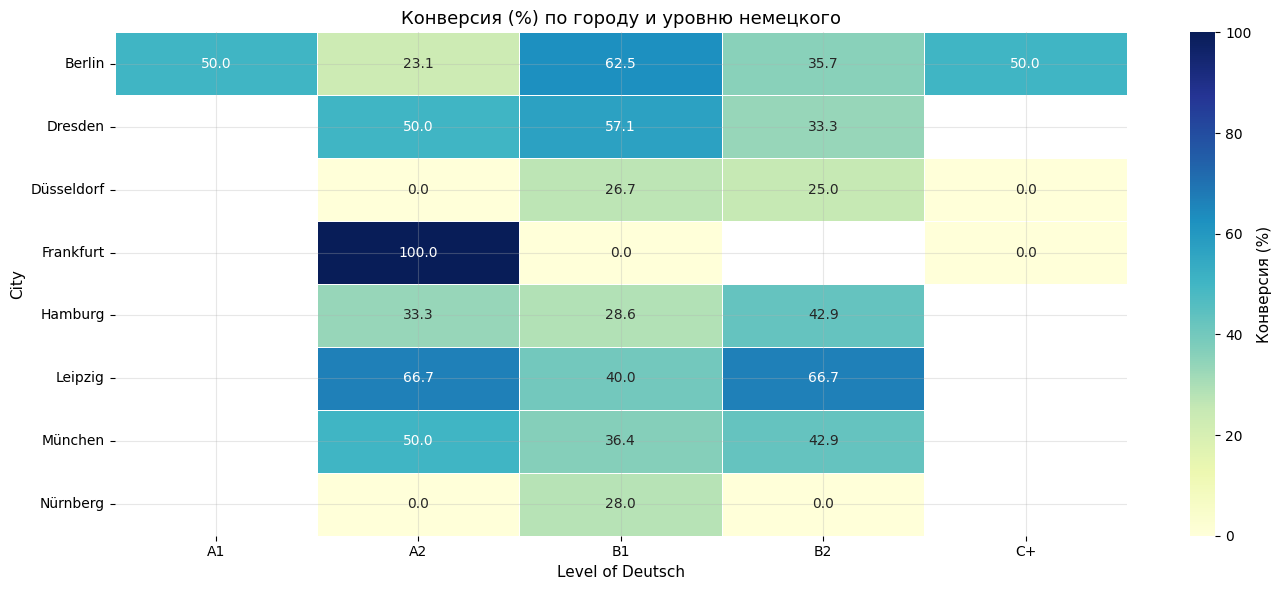

In [99]:
# Select top 8 cities for better heatmap readability
top8_cities = city_analysis.head(8)["City"].tolist()

deutsch_city = (
    deals[
        deals["City"].isin(top8_cities)
        & (deals["Level of Deutsch"] != "Unknown")
    ]
    .groupby(["City", "Level of Deutsch"], observed=True)
    .agg(total=("Id", "count"), paid=("Is Paid", "sum"))
    .reset_index()
)
deutsch_city["conversion_pct"] = (
    deutsch_city["paid"] / deutsch_city["total"] * 100
).round(2)

pivot = deutsch_city.pivot_table(
    index="City",
    columns="Level of Deutsch",
    values="conversion_pct",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot, annot=True, fmt=".1f",
    cmap="YlGnBu", linewidths=0.5, ax=ax,
    cbar_kws={"label": "Conversion Rate (%)"}
)
ax.set_title("Conversion Rate (%) by City and German Language Level",
             fontsize=13)
plt.tight_layout()
plt.show()

# 20. Export for Tableau

In [100]:
# Tableau works with CSV files
# Convert Period columns to strings for correct import
deals_export = deals.copy()

# Convert Period columns to strings
for col in ["Created Month", "Closing Month"]:
    if col in deals_export.columns:
        deals_export[col] = deals_export[col].astype(str)

# Convert ordered categorical columns to strings
if hasattr(deals_export["Level of Deutsch"], "cat"):
    deals_export["Level of Deutsch"] = deals_export["Level of Deutsch"].astype(str)

deals_export.to_csv(
    "../data/clean/deals_for_tableau.csv",
    index=False,
    encoding="utf-8-sig"
)
print("deals_for_tableau.csv saved.")

deals_for_tableau.csv сохранён.


In [101]:
# Spend
spend_export = spend.copy()

for col in spend_export.columns:
    if str(spend_export[col].dtype).startswith("period"):
        spend_export[col] = spend_export[col].astype(str)

spend_export.to_csv(
    "../data/clean/spend_for_tableau.csv",
    index=False,
    encoding="utf-8-sig"
)

print("spend_for_tableau.csv saved.")

spend_for_tableau.csv сохранён.


In [102]:
# Product summary
product_analysis.to_csv(
    "../data/clean/product_summary_for_tableau.csv",
    index=False,
    encoding="utf-8-sig"
)
print("product_summary_for_tableau.csv saved.")

product_summary_for_tableau.csv сохранён.


In [103]:
# Sales representative summary
manager_perf.to_csv(
    "../data/clean/manager_perf_for_tableau.csv",
    index=False,
    encoding="utf-8-sig"
)
print("manager_perf_for_tableau.csv saved.")

manager_perf_for_tableau.csv сохранён.


In [104]:
# City summary
city_analysis.to_csv(
    "../data/clean/city_analysis_for_tableau.csv",
    index=False,
    encoding="utf-8-sig"
)
print("city_analysis_for_tableau.csv saved.")

city_analysis_for_tableau.csv сохранён.


In [108]:
contacts.to_csv(
    "../data/clean/contacts_for_tableau.csv",
    index=False,
    encoding="utf-8-sig"
)

print("contacts_for_tableau.csv saved.")

contacts_for_tableau.csv сохранён.


In [109]:
calls.to_csv(
    "../data/clean/calls_for_tableau.csv",
    index=False,
    encoding="utf-8-sig"
)

print("calls_for_tableau.csv saved.")

calls_for_tableau.csv сохранён.
